In [ ]:
import pandas as pd
import seaborn as sns

In [20]:
df=sns.load_dataset('iris')

In [21]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [22]:
df.duplicated().sum()

np.int64(1)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [26]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['species']=encoder.fit_transform(df['species'])


In [27]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [28]:
x=df.drop(columns=['species'])
y=df['species']

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [30]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((104, 4), (45, 4), (104,), (45,))

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model=DecisionTreeClassifier(criterion='entropy')
model.fit(x_train,y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.375, 0.9285714285714286, 'x[3] <= 0.8\nentropy = 1.574\nsamples = 104\nvalue = [36, 39, 29]'),
 Text(0.25, 0.7857142857142857, 'entropy = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.3125, 0.8571428571428572, 'True  '),
 Text(0.5, 0.7857142857142857, 'x[2] <= 4.85\nentropy = 0.984\nsamples = 68\nvalue = [0, 39, 29]'),
 Text(0.4375, 0.8571428571428572, '  False'),
 Text(0.25, 0.6428571428571429, 'x[0] <= 4.95\nentropy = 0.179\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.125, 0.5, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.375, 0.5, 'entropy = 0.0\nsamples = 36\nvalue = [0, 36, 0]'),
 Text(0.75, 0.6428571428571429, 'x[3] <= 1.75\nentropy = 0.459\nsamples = 31\nvalue = [0, 3, 28]'),
 Text(0.625, 0.5, 'x[2] <= 5.35\nentropy = 0.985\nsamples = 7\nvalue = [0, 3, 4]'),
 Text(0.5, 0.35714285714285715, 'x[3] <= 1.55\nentropy = 0.971\nsamples = 5\nvalue = [0, 3, 2]'),
 Text(0.375, 0.21428571428571427, 'x[2] <= 4.95\nentropy = 0.918\nsamples = 3\nvalue = [0, 1, 2]'),
 T

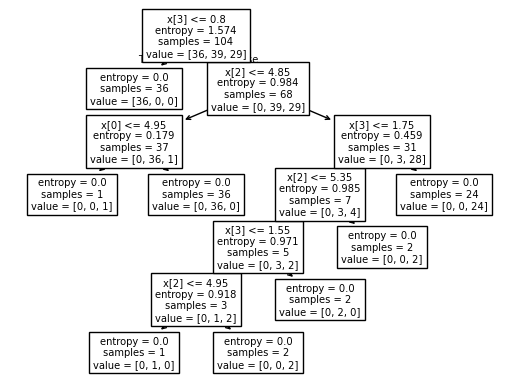

In [32]:
tree.plot_tree(model)

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model=DecisionTreeClassifier(criterion='entropy',max_depth=2)
model.fit(x_train,y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\nentropy = 1.574\nsamples = 104\nvalue = [36, 39, 29]'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 36\nvalue = [36, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.85\nentropy = 0.984\nsamples = 68\nvalue = [0, 39, 29]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.179\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.459\nsamples = 31\nvalue = [0, 3, 28]')]

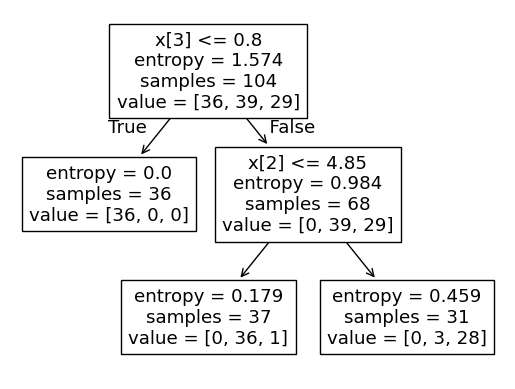

In [34]:
tree.plot_tree(model)

In [35]:
df['species'].value_counts()

species
0    50
1    50
2    49
Name: count, dtype: int64

In [36]:
y_pred=model.predict(x_test)
y_pred

array([2, 0, 0, 0, 2, 1, 2, 2, 1, 0, 0, 1, 1, 2, 2, 2, 2, 1, 1, 0, 1, 2,
       2, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1,
       1])

In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.83      0.91      0.87        11
           2       0.95      0.90      0.92        20

    accuracy                           0.93        45
   macro avg       0.93      0.94      0.93        45
weighted avg       0.94      0.93      0.93        45



In [38]:
model.predict([[3.5,2.9,4.2,4.0]])

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])